# JWST/MIRI SN1983V Photometry Notebook

- Written by Justin Pierel
- Edited / Formatted by Sophie Kressy

In [1]:
%matplotlib inline

#### make sure to update working directory


In [2]:
import sys,os,glob,shutil
import tarfile, urllib.request

# update this path to your working directory!!
os.environ["STPSF_PATH"] = '/Users/sophiakressy/Library/Mobile Documents/com~apple~CloudDocs/Desktop/VS_Workspace/sn_dust/stpsf-data/stpsf-data/'
os.environ["PYSYN_CDBS"] = "/Users/sophiakressy/Library/Mobile Documents/com~apple~CloudDocs/Desktop/VS_Workspace/sn_dust/grp"

# WEBBPSF Data
#boxlink = 'https://stsci.box.com/shared/static/qxpiaxsjwo15ml6m4pkhtk36c9jgj70k.gz'  
boxlink = 'https://stsci.box.com/shared/static/kqfolg2bfzqc4mjkgmujo06d3iaymahv.gz'
#boxfile = './webbpsf-data/webbpsf-data-1.0.0.tar.gz'
boxfile = './stpsf-data/stpsf-data-LATEST.tar.gz'
synphot_url = 'http://ssb.stsci.edu/trds/tarfiles/synphot5.tar.gz'
synphot_file = './synphot5.tar.gz'

#webbpsf_folder = './webbpsf-data'
stpsf_folder = "./stpsf-data"
synphot_folder = './grp'

# Gather webbpsf files
#psfExist = os.path.exists(webbpsf_folder)
psfExist = os.path.exists(stpsf_folder)
if not psfExist:
    os.makedirs(stpsf_folder)
    urllib.request.urlretrieve(boxlink, boxfile)
    gzf = tarfile.open(boxfile)
    gzf.extractall(stpsf_folder)

# Gather synphot files
synExist = os.path.exists(synphot_folder)
if not synExist:
    os.makedirs(synphot_folder)
    urllib.request.urlretrieve(synphot_url, synphot_file)
    gzf = tarfile.open(synphot_file)
    gzf.extractall('./')

Import functions

In [3]:
import numpy as np
import sys,os,glob
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from astropy.nddata import extract_array
from astropy.coordinates import SkyCoord
from astropy import wcs
from astropy.wcs.utils import skycoord_to_pixel
from astropy import units as u
# from astroquery.mast import Observations
from astropy.visualization import (simple_norm,LinearStretch)
from astropy.wcs import WCS
from photutils.centroids import centroid_com, centroid_sources, centroid_2dg, centroid_quadratic
from photutils.centroids import (centroid_1dg, centroid_2dg,
                                 centroid_com, centroid_quadratic)
from photutils.datasets import make_4gaussians_image
# import jhat
# from jhat import hst_photclass,st_wcs_align
import space_phot
from stwcs.updatewcs import wcsutil
import shutil
import drizzlepac
import stpsf


/Users/sophiakressy/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm




The following task in the stsci.skypac package can be run with TEAL:
                                    skymatch                                    


**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-072
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf


## Select level 2 and level 3 file paths

In [5]:
# SN 1983V
lvl2 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/*skysub_cal.fits'
lvl3 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/*jhat_i2d.fits'
lvl3_single = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f770w_jhat_i2d.fits'
# lvl3_single_1130 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-c1003_t003_miri_f1130w_jhat_i2d.fits'

ra  = '3:33:31.6159' #unit=(u.hourangle,u.deg)) #icrs
dec = '-36:08:55.222' #unit=(u.hourangle,u.deg)) #icrs

### grab files

In [6]:
files = glob.glob(lvl2) #lvl2
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter_arr

['F2100W', 'F1000W', 'F770W', 'F1000W', 'F1130W', 'F770W', 'F2100W', 'F1130W', 'F1000W', 'F770W', 'F770W', 'F2100W', 'F1000W', 'F1130W', 'F2100W', 'F1130W', 'F1000W', 'F770W', 'F770W', 'F1130W', 'F2100W', 'F1130W', 'F2100W', 'F1000W', 'F1130W', 'F770W', 'F1000W', 'F1000W', 'F2100W', 'F1130W', 'F2100W', 'F770W', 'F1130W', 'F1130W', 'F1000W', 'F2100W', 'F2100W', 'F1000W', 'F770W', 'F770W', 'F2100W', 'F770W', 'F1130W', 'F770W', 'F2100W', 'F1130W', 'F1000W', 'F1000W', 'F1130W', 'F770W', 'F2100W', 'F1000W', 'F1130W', 'F2100W', 'F770W', 'F1000W', 'F2100W', 'F2100W', 'F1130W', 'F1000W', 'F1130W', 'F770W', 'F770W', 'F1000W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_09101_00002_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003003_05101_00001_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003002_03101_00003_mirimage_skysub_cal.fits', '/Users/sophiakre

['F2100W',
 'F1000W',
 'F770W',
 'F1000W',
 'F1130W',
 'F770W',
 'F2100W',
 'F1130W',
 'F1000W',
 'F770W',
 'F770W',
 'F2100W',
 'F1000W',
 'F1130W',
 'F2100W',
 'F1130W',
 'F1000W',
 'F770W',
 'F770W',
 'F1130W',
 'F2100W',
 'F1130W',
 'F2100W',
 'F1000W',
 'F1130W',
 'F770W',
 'F1000W',
 'F1000W',
 'F2100W',
 'F1130W',
 'F2100W',
 'F770W',
 'F1130W',
 'F1130W',
 'F1000W',
 'F2100W',
 'F2100W',
 'F1000W',
 'F770W',
 'F770W',
 'F2100W',
 'F770W',
 'F1130W',
 'F770W',
 'F2100W',
 'F1130W',
 'F1000W',
 'F1000W',
 'F1130W',
 'F770W',
 'F2100W',
 'F1000W',
 'F1130W',
 'F2100W',
 'F770W',
 'F1000W',
 'F2100W',
 'F2100W',
 'F1130W',
 'F1000W',
 'F1130W',
 'F770W',
 'F770W',
 'F1000W']

## Get Centroid

In [7]:
f = fits.open(lvl3_single)
data = f[1].data
w = WCS(f[1].header)

initial_location = SkyCoord(ra,dec,unit=(u.hourangle,u.deg)) #icrs
print(initial_location)

x_init, y_init = wcs.utils.skycoord_to_pixel(initial_location,w)
print(x_init, y_init)

x_cent, y_cent = centroid_sources(data, x_init, y_init, box_size=3, centroid_func=centroid_2dg)
print(x_cent,y_cent)

centered_location = wcs.utils.pixel_to_skycoord(x_cent[0],y_cent[0],w)
print(centered_location)

sn_location = centered_location
print(sn_location)

<SkyCoord (ICRS): (ra, dec) in deg
    (53.38173292, -36.14867278)>
1137.554594329321 1243.3071850688011
[1137.46869833] [1242.62863838]
<SkyCoord (ICRS): (ra, dec) in deg
    (53.38175848, -36.14866849)>
<SkyCoord (ICRS): (ra, dec) in deg
    (53.38175848, -36.14866849)>


### Create a PSF using SPACE_PHOT in these DRZ tweakback images


# MIRI F770W

In [8]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F770W']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F770W'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)
drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()

['F770W', 'F770W', 'F770W', 'F770W', 'F770W', 'F770W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_03101_00001_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_03101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_03101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_03101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_03101_00002_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_03101_00003_mirimage_skysub_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli

### Run PSF fit

2025-12-08 13:36:00,471 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-12-08 13:36:00,472 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-12-08 13:36:00,473 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-12-08 13:36:00,473 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-12-08 13:36:00,474 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-12-08 13:36:00,474 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-12-08 13:36:00,475 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-12-08 13:36:00,537 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-12-08 13:36:00,542 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

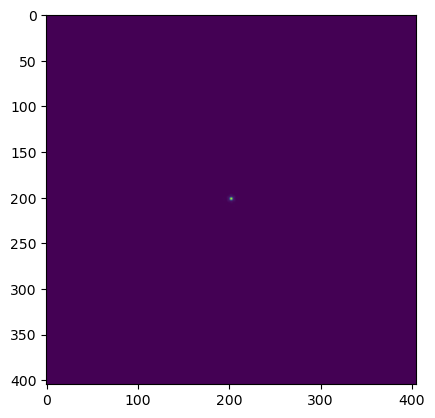

In [9]:
jwst_flc_obs = space_phot.observation2(input_flcs)
jwst_drz_obs = space_phot.observation3(input_drzs[0])
# has attributes .upper_limit, .psf_photometry, .create_psf_subtracted, .aperature_photometry, .plant_psf

# input_drzs[0] # use this as data and error
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4) # this uses photutils to find PSF

plt.imshow(psf_drz.data)
plt.show()

3795it [00:01, 2176.31it/s, +200 | bound: 29 | nc: 1 | ncall: 15929 | eff(%): 25.399 | loglstar:   -inf < -5.484 <    inf | logz: -22.805 +/-  0.283 | dlogz:  0.001 >  0.209]


[3.76070349 0.11814483 0.11391472 0.1940559 ]
0.32769292985111476
[1.23235594 0.03871523 0.03732905 0.06359075]
Finished PSF psf_photometry with median residuals of 8.34%


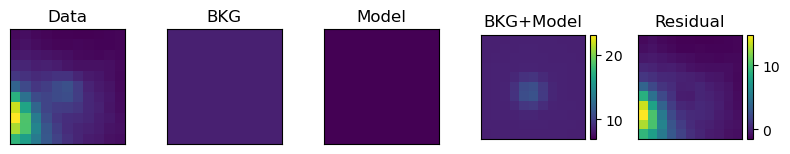

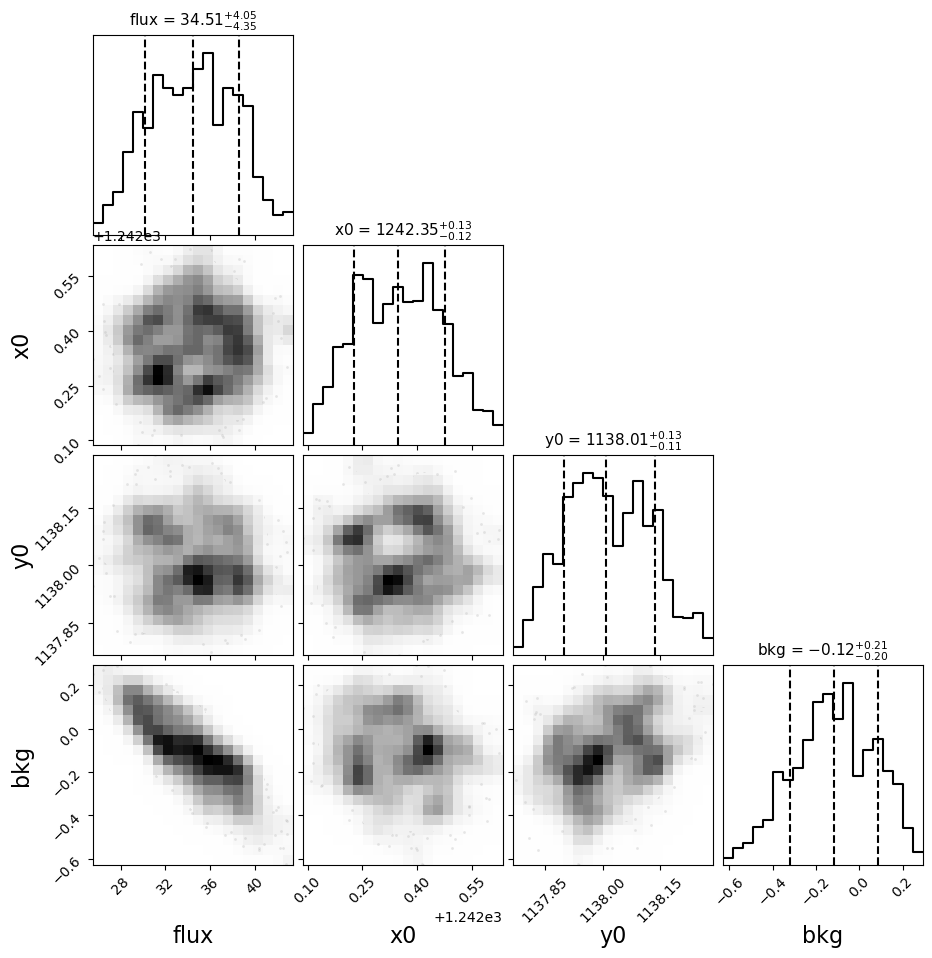

In [10]:
jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,10]},
                            fit_width=11,
                            background = 8.5,
                            fit_bkg=True,
                            fit_centroid=True, 
                            fit_flux=True,
                            centroidx_shift=0,
                            centroidy_shift=0,
                            psf_method='nest',
                            center_weight=25,npoints=200)

jwst_drz_obs.plot_psf_fit()
plt.show()

jwst_drz_obs.plot_psf_posterior(minweight=0.001)
plt.show()

#### Print magnitude and error

In [14]:
# print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])
# print(jwst_drz_obs.psf_result.phot_cal_table['flux'])
# print(jwst_drz_obs.psf_result.phot_cal_table['fluxerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

       mag               magerr      
----------------- -------------------
21.40632207655329 0.11276399026555196


#### Calculate Flux in Janskys

In [ ]:
flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  9.94194072229633e-06
FLUX ERROR [Jy] =  1.0325647260509889e-06


# MIRI F1000W

In [19]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F1000W']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F1000W'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)
drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()

['F1000W', 'F1000W', 'F1000W', 'F1000W', 'F1000W', 'F1000W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_05101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_05101_00002_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_05101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_05101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_05101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_05101_00001_mirimage_skysub_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop

### Run PSF fit

2025-12-08 13:41:30,776 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-12-08 13:41:30,777 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-12-08 13:41:30,778 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-12-08 13:41:30,779 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-12-08 13:41:30,779 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-12-08 13:41:30,780 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-12-08 13:41:30,781 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-12-08 13:41:30,853 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-12-08 13:41:30,859 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

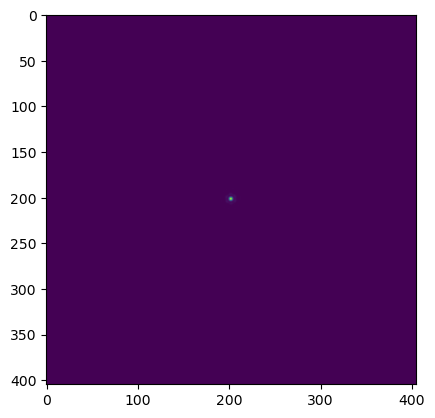

In [20]:
jwst_flc_obs = space_phot.observation2(input_flcs)
jwst_drz_obs = space_phot.observation3(input_drzs[0])

psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

4037it [00:01, 2337.31it/s, +200 | bound: 30 | nc: 1 | ncall: 15870 | eff(%): 27.039 | loglstar:   -inf < -1.146 <    inf | logz: -19.674 +/-  0.293 | dlogz:  0.001 >  0.209]


[5.88639485 0.04488057 0.04596596 0.25393647]
0.32769292985111476
[1.92892997 0.01470705 0.01506272 0.08321319]
Finished PSF psf_photometry with median residuals of 1.52%


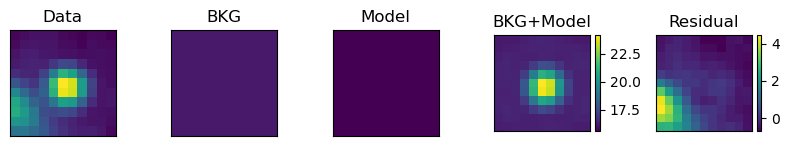

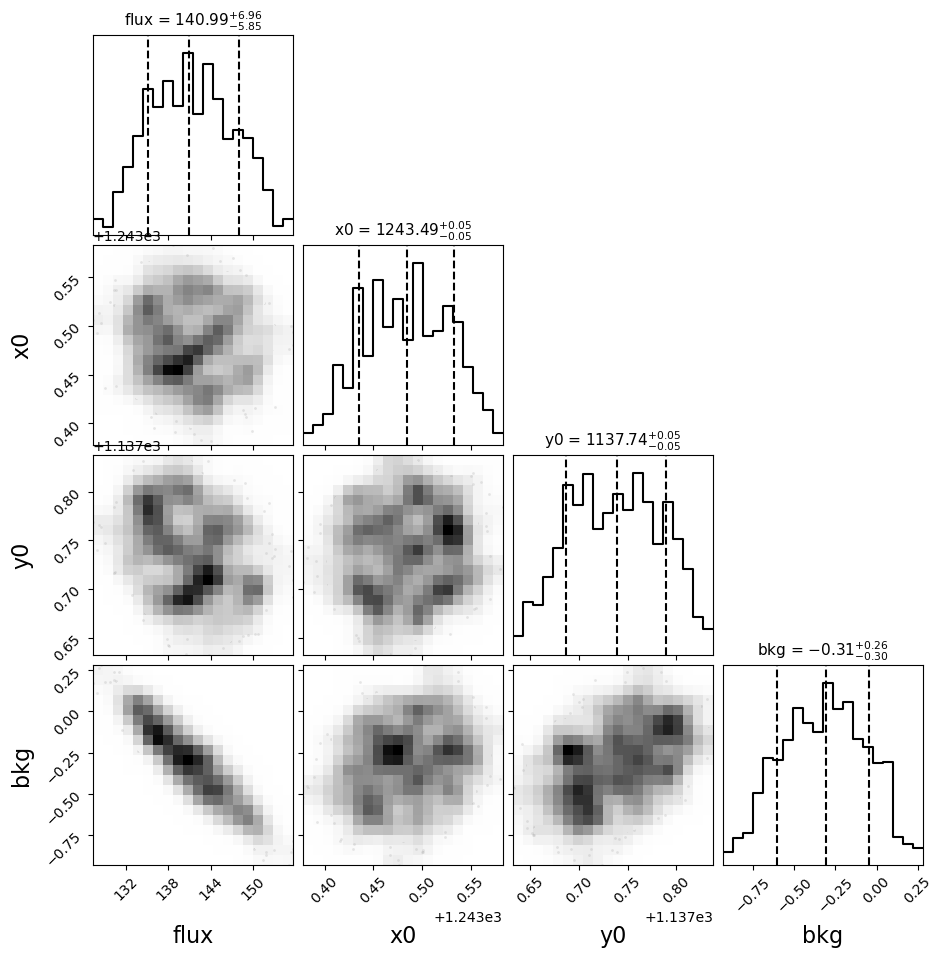

In [21]:
jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,10]},
                            fit_width=11,
                            background = 16.5,
                            fit_bkg=True,
                            fit_centroid=True, 
                            fit_flux=True,
                            centroidx_shift=0,
                            centroidy_shift=0,
                            psf_method='nest',
                            center_weight=25,npoints=200)

jwst_drz_obs.plot_psf_fit()
plt.show()

jwst_drz_obs.plot_psf_posterior(minweight=0.001)
plt.show()

#### Print magnitude and error

In [23]:
# print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])
# print(jwst_drz_obs.psf_result.phot_cal_table['flux'])
# print(jwst_drz_obs.psf_result.phot_cal_table['fluxerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

       mag                magerr      
------------------ -------------------
19.870873373953533 0.04430253628633486


#### Calculate Flux

In [24]:
flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  4.0893157990867455e-05
FLUX ERROR [Jy] =  1.6686103012994926e-06


# MIRI F1130W

In [26]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F1130W']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F1130W'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)

drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()
input_drzs


['F1130W', 'F1130W', 'F1130W', 'F1130W', 'F1130W', 'F1130W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_07101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_07101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_07101_00002_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_07101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_07101_00001_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_07101_00003_mirimage_skysub_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop

['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f1130w_jhat_i2d.fits']

2025-12-08 13:45:11,142 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-12-08 13:45:11,142 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-12-08 13:45:11,143 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-12-08 13:45:11,144 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-12-08 13:45:11,145 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-12-08 13:45:11,145 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-12-08 13:45:11,146 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-12-08 13:45:11,212 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-12-08 13:45:11,217 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

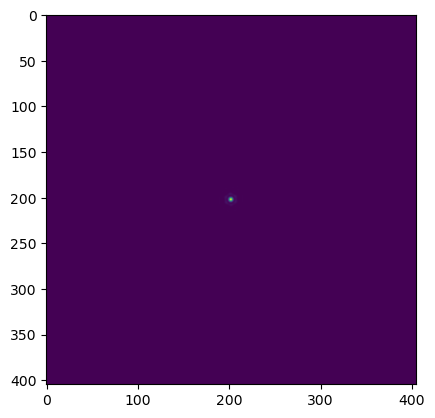

In [27]:
jwst_flc_obs = space_phot.observation2(input_flcs)
jwst_drz_obs = space_phot.observation3(input_drzs[0])
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

0it [00:00, ?it/s]

3897it [00:01, 2050.77it/s, +200 | bound: 30 | nc: 1 | ncall: 16641 | eff(%): 24.919 | loglstar:   -inf < -10.169 <    inf | logz: -28.003 +/-  0.287 | dlogz:  0.001 >  0.209]


[8.1092938  0.05983175 0.06536728 0.29791092]
0.32769292985111476
[2.65735825 0.01960644 0.0214204  0.0976233 ]
Finished PSF psf_photometry with median residuals of 2.75%


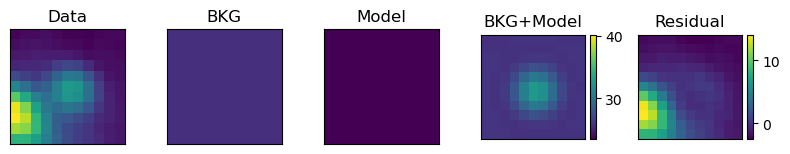

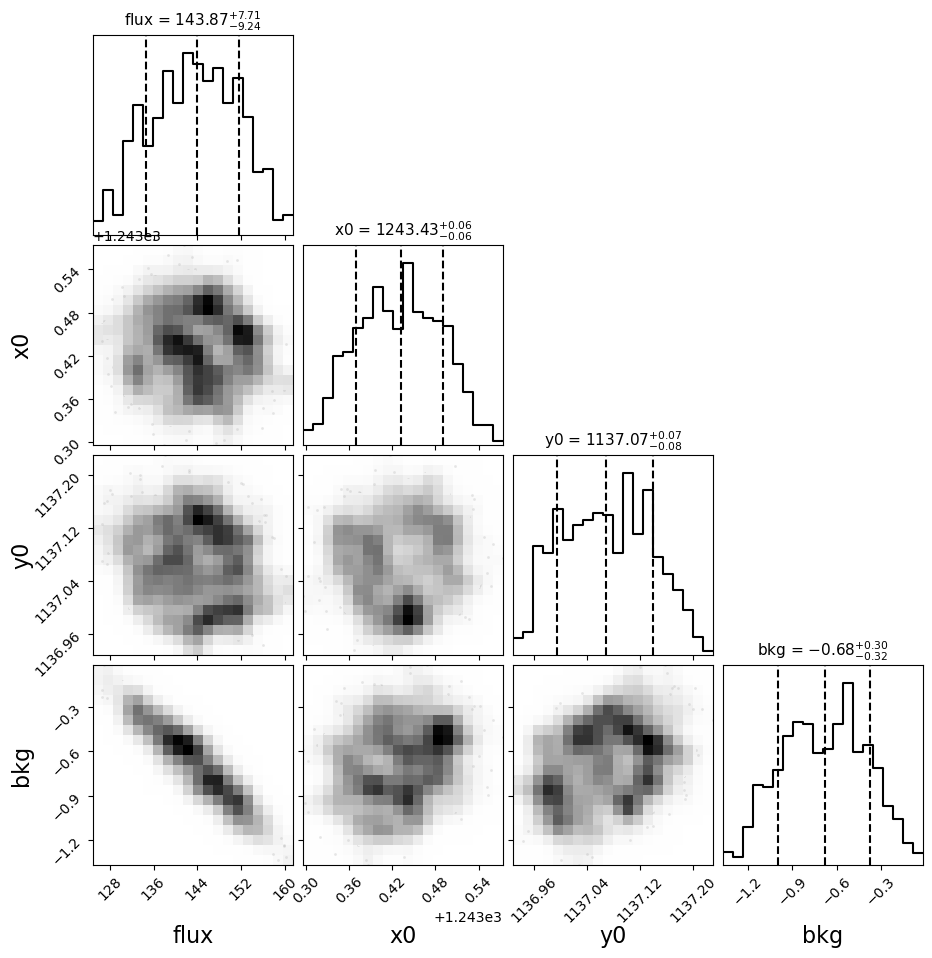

In [28]:
jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,10]},
                            fit_width=11,
                            background = 26.5,
                            fit_bkg=True,
                            fit_centroid=True, 
                            fit_flux=True,
                            centroidx_shift=0,
                            centroidy_shift=0,
                            psf_method='nest',
                            center_weight=25,npoints=200)

jwst_drz_obs.plot_psf_fit()
plt.show()

jwst_drz_obs.plot_psf_posterior(minweight=0.001)
plt.show()

#### Print magnitude and error

In [29]:
# print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])
# print(jwst_drz_obs.psf_result.phot_cal_table['flux'])
# print(jwst_drz_obs.psf_result.phot_cal_table['fluxerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

       mag              magerr     
----------------- -----------------
19.85579415911944 0.059760505624042


#### Calculate Flux

In [30]:
flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  4.1465063648045497e-05
FLUX ERROR [Jy] =  2.282297632224858e-06


# MIRI F2100W

In [33]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F2100W']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F2100W'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)
drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()

['F2100W', 'F2100W', 'F2100W', 'F2100W', 'F2100W', 'F2100W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_09101_00002_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_09101_00004_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_09101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003004_09101_00003_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_09101_00001_mirimage_skysub_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107003001_09101_00004_mirimage_skysub_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop

### Run PSF fit

2025-12-08 13:47:17,016 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-12-08 13:47:17,017 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-12-08 13:47:17,018 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-12-08 13:47:17,019 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-12-08 13:47:17,020 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-12-08 13:47:17,020 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-12-08 13:47:17,021 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-12-08 13:47:17,086 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-12-08 13:47:17,091 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

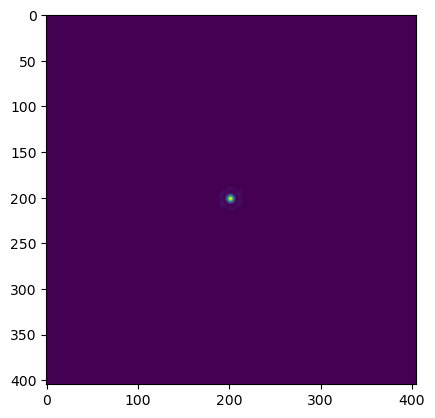

In [34]:
jwst_flc_obs = space_phot.observation2(input_flcs)
jwst_drz_obs = space_phot.observation3(input_drzs[0])

psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

4541it [00:02, 1884.81it/s, +200 | bound: 42 | nc: 1 | ncall: 20006 | eff(%): 23.937 | loglstar:   -inf < -9.615 <    inf | logz: -30.674 +/-  0.313 | dlogz:  0.001 >  0.209]    


[38.4932888   0.12019746  0.04092861  0.5595709 ]
0.32769292985111476
[12.61397859  0.03938786  0.01341202  0.18336743]
Finished PSF psf_photometry with median residuals of 0.38%


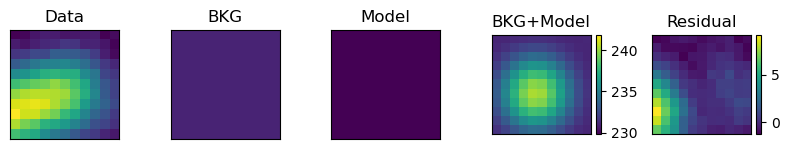

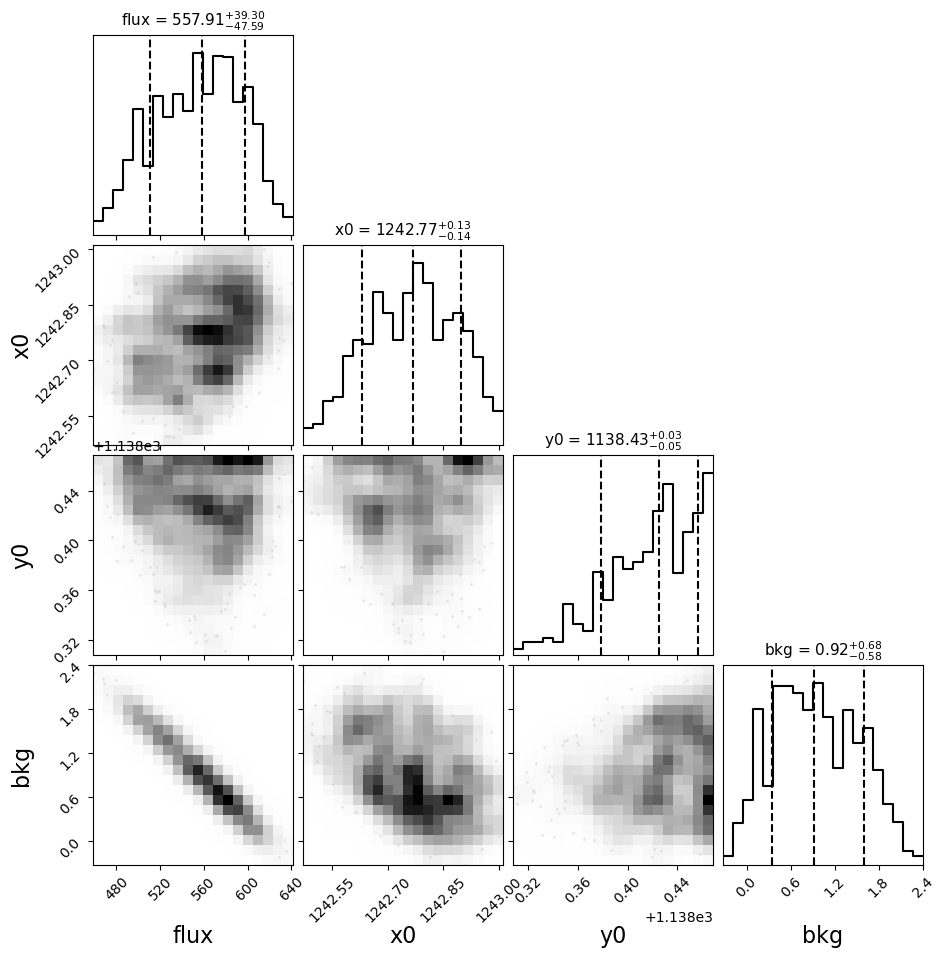

In [37]:
jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,1000]},
                            fit_width=11,
                            background = 230,
                            fit_bkg=True,
                            fit_centroid=True, 
                            fit_flux=True,
                            centroidx_shift=0,
                            centroidy_shift=0,
                            psf_method='nest',
                            center_weight=25,npoints=200)

jwst_drz_obs.plot_psf_fit()
plt.show()

jwst_drz_obs.plot_psf_posterior(minweight=0.001)
plt.show()

#### Print magnitude and error

In [38]:
# print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])
# print(jwst_drz_obs.psf_result.phot_cal_table['flux'])
# print(jwst_drz_obs.psf_result.phot_cal_table['fluxerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

       mag               magerr      
------------------ ------------------
18.389152339951675 0.0730263038845084


#### Calculate Flux

In [39]:
flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  0.00016008073291833336
FLUX ERROR [Jy] =  1.076698391093374e-05


## ----------------------------------------------------------------------------------------
## ----------------------------------------------------------------------------------------

# NIRCAM F200W

### Grab files

In [41]:
# SN 1983V
lvl2 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/*_cal.fits'
lvl3 = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/*jhat_i2d.fits'
lvl3_single = '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f200w_jhat_i2d.fits'

ra  = '3:33:31.6159' #unit=(u.hourangle,u.deg)) #icrs
dec = '-36:08:55.222' #unit=(u.hourangle,u.deg)) #icrs


In [42]:
files = glob.glob(lvl2) #lvl2
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter_arr

['F200W', 'F2100W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F1000W', 'F770W', 'F200W', 'F1000W', 'F1130W', 'F200W', 'F200W', 'F200W', 'F300M', 'F770W', 'F200W', 'F335M', 'F360M', 'F200W', 'F2100W', 'F1130W', 'F200W', 'F200W', 'F200W', 'F1000W', 'F770W', 'F360M', 'F770W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F2100W', 'F360M', 'F1000W', 'F1130W', 'F200W', 'F2100W', 'F200W', 'F1130W', 'F300M', 'F335M', 'F360M', 'F200W', 'F360M', 'F200W', 'F300M', 'F1000W', 'F200W', 'F770W', 'F200W', 'F200W', 'F200W', 'F770W', 'F200W', 'F200W', 'F200W', 'F1130W', 'F200W', 'F200W', 'F200W', 'F200W', 'F2100W', 'F1130W', 'F300M', 'F2100W', 'F1000W', 'F200W', 'F200W', 'F1130W', 'F200W', 'F200W', 'F200W', 'F360M', 'F200W', 'F200W', 'F200W', 'F770W', 'F200W', 'F200W', 'F200W', 'F360M', 'F1000W', 'F200W', 'F200W', 'F200W', 'F335M', 'F1000W', 'F2100W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F335M', 'F200W', 'F200W', 'F360M', 'F200W', 'F1130W', 'F21

['F200W',
 'F2100W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F1000W',
 'F770W',
 'F200W',
 'F1000W',
 'F1130W',
 'F200W',
 'F200W',
 'F200W',
 'F300M',
 'F770W',
 'F200W',
 'F335M',
 'F360M',
 'F200W',
 'F2100W',
 'F1130W',
 'F200W',
 'F200W',
 'F200W',
 'F1000W',
 'F770W',
 'F360M',
 'F770W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F2100W',
 'F360M',
 'F1000W',
 'F1130W',
 'F200W',
 'F2100W',
 'F200W',
 'F1130W',
 'F300M',
 'F335M',
 'F360M',
 'F200W',
 'F360M',
 'F200W',
 'F300M',
 'F1000W',
 'F200W',
 'F770W',
 'F200W',
 'F200W',
 'F200W',
 'F770W',
 'F200W',
 'F200W',
 'F200W',
 'F1130W',
 'F200W',
 'F200W',
 'F200W',
 'F200W',
 'F2100W',
 'F1130W',
 'F300M',
 'F2100W',
 'F1000W',
 'F200W',
 'F200W',
 'F1130W',
 'F200W',
 'F200W',
 'F200W',
 'F360M',
 'F200W',
 'F200W',
 'F200W',
 'F770W',
 'F200W',
 'F200W',
 'F200W',
 'F360M',
 'F1000W',
 'F200W',
 'F200W',
 'F200W',
 'F335M',
 'F1000W',
 'F2100W',
 'F200W'

### Centroid

In [43]:
f = fits.open(lvl3_single)
data = f[1].data
w = WCS(f[1].header)

initial_location = SkyCoord(ra,dec,unit=(u.hourangle,u.deg)) #icrs
print(initial_location)

x_init, y_init = wcs.utils.skycoord_to_pixel(initial_location,w)
print(x_init, y_init)

x_cent, y_cent = centroid_sources(data, x_init, y_init, box_size=3, centroid_func=centroid_2dg)
print(x_cent,y_cent)

centered_location = wcs.utils.pixel_to_skycoord(x_cent[0],y_cent[0],w)
print(centered_location)

sn_location = centered_location
print(sn_location)

<SkyCoord (ICRS): (ra, dec) in deg
    (53.38173292, -36.14867278)>
2590.898681841159 5376.109602703007
[2590.85447829] [5375.43462423]
<SkyCoord (ICRS): (ra, dec) in deg
    (53.3817399, -36.14867154)>
<SkyCoord (ICRS): (ra, dec) in deg
    (53.3817399, -36.14867154)>


### Now run through filters

In [44]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F200W']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F200W'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)

drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()
input_drzs

input_flcs



['F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W', 'F200W']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00004_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00003_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00001_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00002_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00002_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00001_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00003_nrcb2_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00004

['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00004_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00003_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00001_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00002_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00002_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00001_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00003_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00004_nrcb2_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00001_nrcb2_cal.fits',
 '/Users/s

#### Run PSF

2025-12-08 13:53:52,858 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-12-08 13:53:52,861 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-12-08 13:53:52,863 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-12-08 13:53:52,864 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-12-08 13:53:52,864 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-12-08 13:53:52,865 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-12-08 13:53:52,866 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-12-08 13:53:53,000 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-12-08 13:53:53,006 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

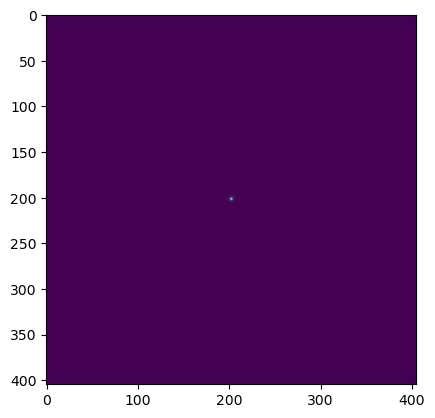

In [45]:
jwst_flc_obs = space_phot.observation2(input_flcs) 
jwst_drz_obs = space_phot.observation3(input_drzs[0])
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

3295it [00:01, 1733.31it/s, +200 | bound: 28 | nc: 1 | ncall: 15437 | eff(%): 22.938 | loglstar:   -inf < -0.661 <    inf | logz: -15.481 +/-  0.261 | dlogz:  0.001 >  0.209]   


[2.29180763 0.53349806 0.52301852 0.12349635]
0.32769292985111476
[0.75100916 0.17482354 0.17138947 0.04046888]
Finished PSF psf_photometry with median residuals of -4.77%


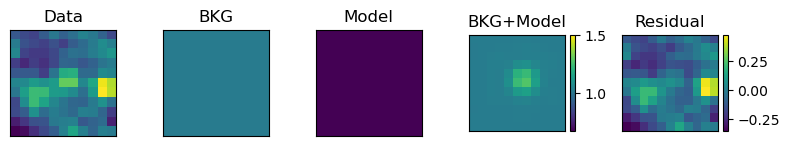

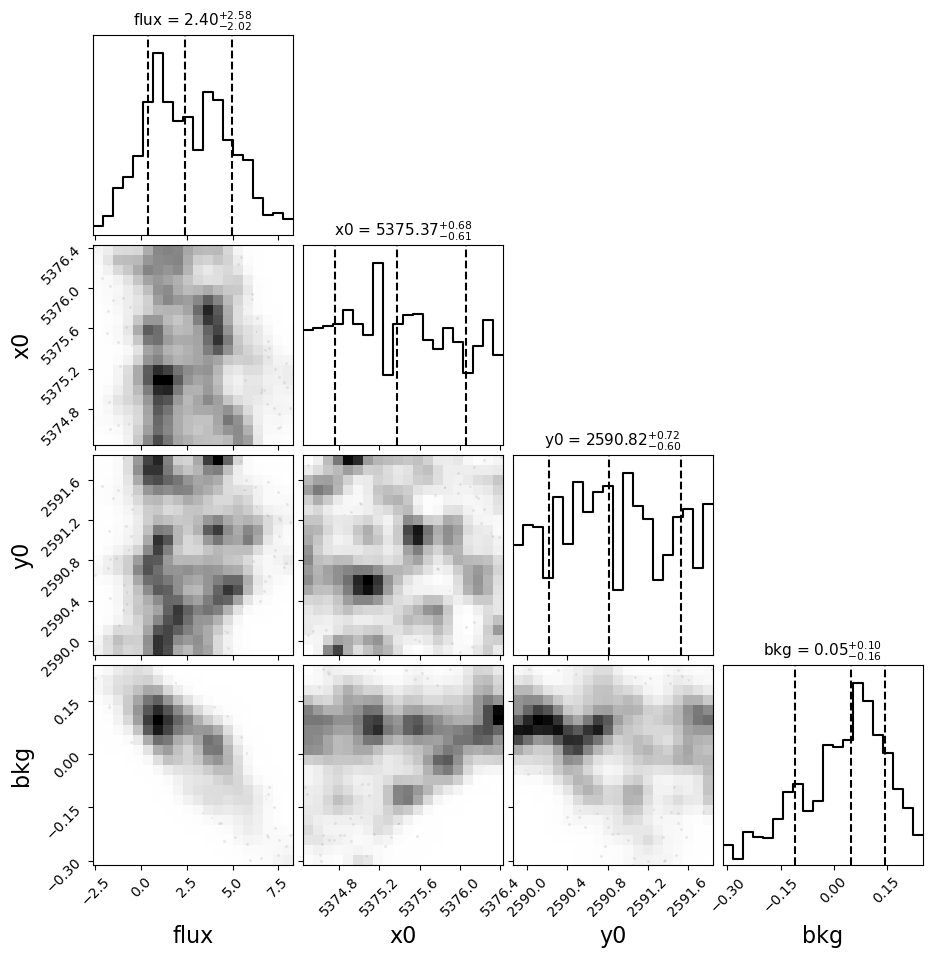

In [46]:
jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,10]},
                            fit_width=11,
                            background = 1,
                            fit_bkg=True,
                            fit_centroid=True, 
                            fit_flux=True,
                            centroidx_shift=0,
                            centroidy_shift=0,
                            psf_method='nest',
                            center_weight=25,npoints=200)

jwst_drz_obs.plot_psf_fit()
plt.show()

jwst_drz_obs.plot_psf_posterior(minweight=0.001)
plt.show()

#### Print magnitude and error

In [47]:
# print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])
# print(jwst_drz_obs.psf_result.phot_cal_table['flux'])
# print(jwst_drz_obs.psf_result.phot_cal_table['fluxerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

       mag               magerr      
------------------ ------------------
26.938806859873665 0.6599653599200538


#### Calculate Flux

In [48]:
flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  6.08803661952421e-08
FLUX ERROR [Jy] =  3.700616467612254e-08


# F300M

In [49]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F300M']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F300M'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)

drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()
input_drzs

input_flcs



['F300M', 'F300M', 'F300M', 'F300M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00004_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00001_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00002_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00003_nrcblong_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f1000w_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f2100w_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_cle

['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00004_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00001_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00002_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_06101_00003_nrcblong_cal.fits']

2025-12-08 13:55:08,964 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-12-08 13:55:08,965 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-12-08 13:55:08,966 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-12-08 13:55:08,967 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-12-08 13:55:08,967 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-12-08 13:55:08,968 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-12-08 13:55:08,968 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-12-08 13:55:09,046 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-12-08 13:55:09,052 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

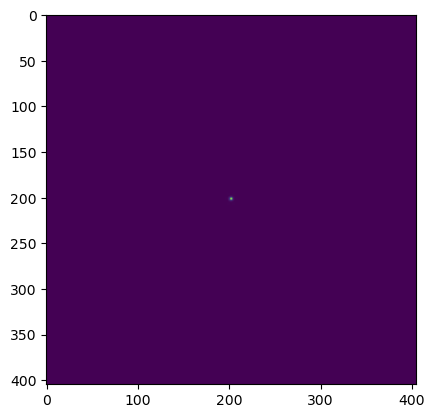

In [50]:
jwst_flc_obs = space_phot.observation2(input_flcs) 
jwst_drz_obs = space_phot.observation3(input_drzs[0])
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

3461it [00:01, 1839.83it/s, +200 | bound: 30 | nc: 1 | ncall: 16117 | eff(%): 23.001 | loglstar:   -inf < -0.136 <    inf | logz: -15.782 +/-  0.269 | dlogz:  0.001 >  0.209]   


[1.50545276 0.56862105 0.55595321 0.09153154]
0.32769292985111476
[0.49332623 0.1863331  0.18218194 0.02999424]
Finished PSF psf_photometry with median residuals of -6.95%


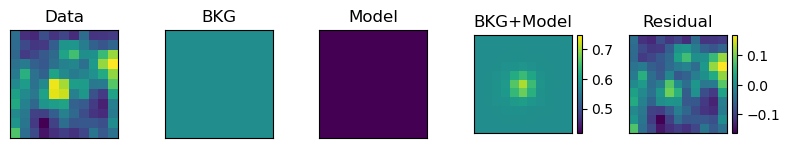

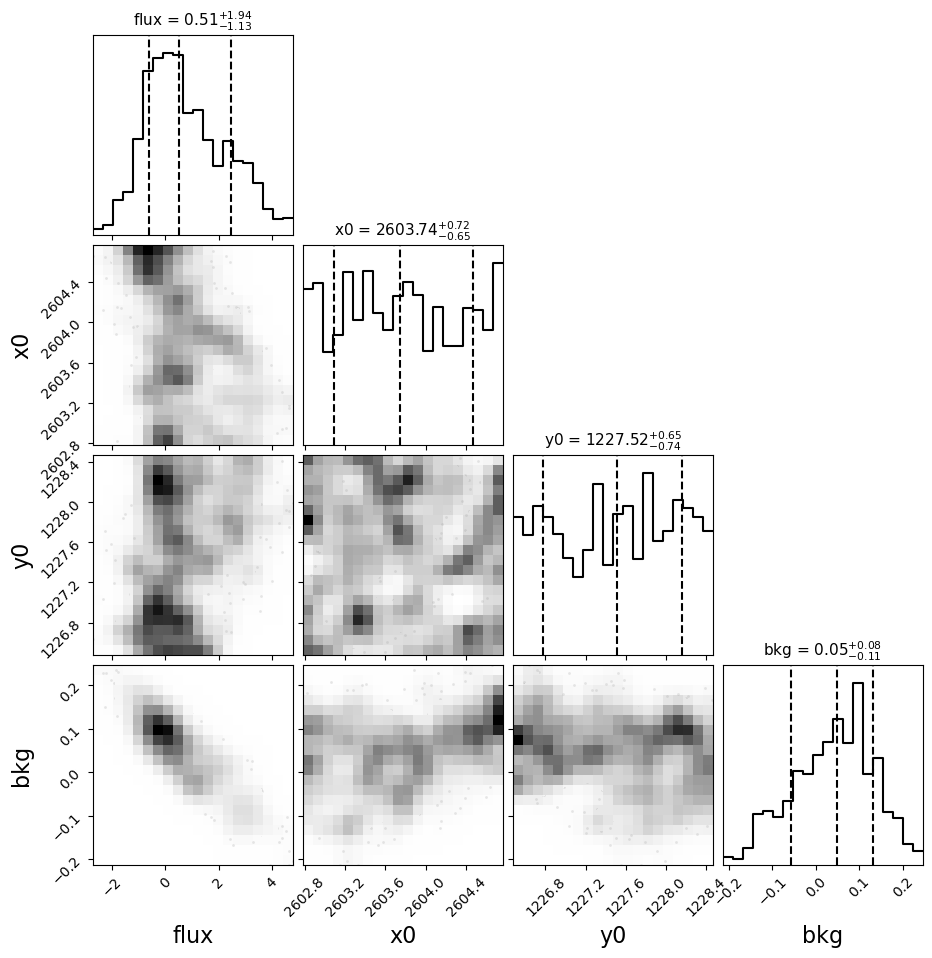

In [51]:
jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,10]},
                            fit_width=11,
                            background = 0.55,
                            fit_bkg=True,
                            fit_centroid=True, 
                            fit_flux=True,
                            centroidx_shift=0,
                            centroidy_shift=0,
                            psf_method='nest',
                            center_weight=25,npoints=200)

jwst_drz_obs.plot_psf_fit()
plt.show()

jwst_drz_obs.plot_psf_posterior(minweight=0.001)
plt.show()

#### Print magnitude and error

In [52]:
# print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])
# print(jwst_drz_obs.psf_result.phot_cal_table['flux'])
# print(jwst_drz_obs.psf_result.phot_cal_table['fluxerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

       mag              magerr      
----------------- ------------------
26.44947374265895 0.9816382218699443


#### Calculate Flux

In [53]:
flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  9.55455584008461e-08
FLUX ERROR [Jy] =  8.63848618523976e-08


# NIRCAM F335M

In [54]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F335M']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F335M'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)

drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()
input_drzs

input_flcs



['F335M', 'F335M', 'F335M', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00002_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00003_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00004_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00001_nrcblong_cal.fits']
['F300M', 'F1000W', 'F2100W', 'F360M', 'F770W', 'F1130W', 'F200W', 'F335M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_clear-f300m_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f1000w_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o003_t003_miri_f2100w_jhat_i2d.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_3/jw02107-o021_t003_nircam_cle

['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00002_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00003_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00004_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_08101_00001_nrcblong_cal.fits']

2025-12-08 13:56:08,120 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-12-08 13:56:08,121 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-12-08 13:56:08,122 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-12-08 13:56:08,123 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-12-08 13:56:08,124 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-12-08 13:56:08,125 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-12-08 13:56:08,125 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-12-08 13:56:08,223 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-12-08 13:56:08,228 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

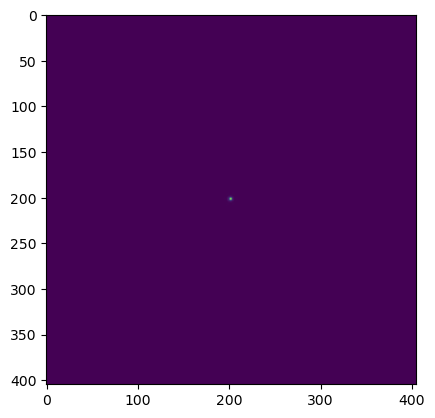

In [55]:
jwst_flc_obs = space_phot.observation2(input_flcs) 
jwst_drz_obs = space_phot.observation3(input_drzs[0])
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

0it [00:00, ?it/s]

3610it [00:02, 1713.47it/s, +200 | bound: 34 | nc: 1 | ncall: 17311 | eff(%): 22.266 | loglstar:   -inf < -0.359 <    inf | logz: -16.758 +/-  0.275 | dlogz:  0.001 >  0.209]   


[1.65591675 0.52436473 0.55813641 0.09857718]
0.32769292985111476
[0.54263221 0.17183062 0.18289736 0.03230304]
Finished PSF psf_photometry with median residuals of -12.78%


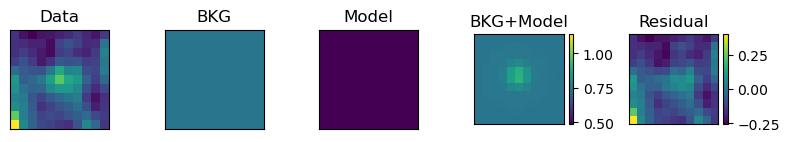

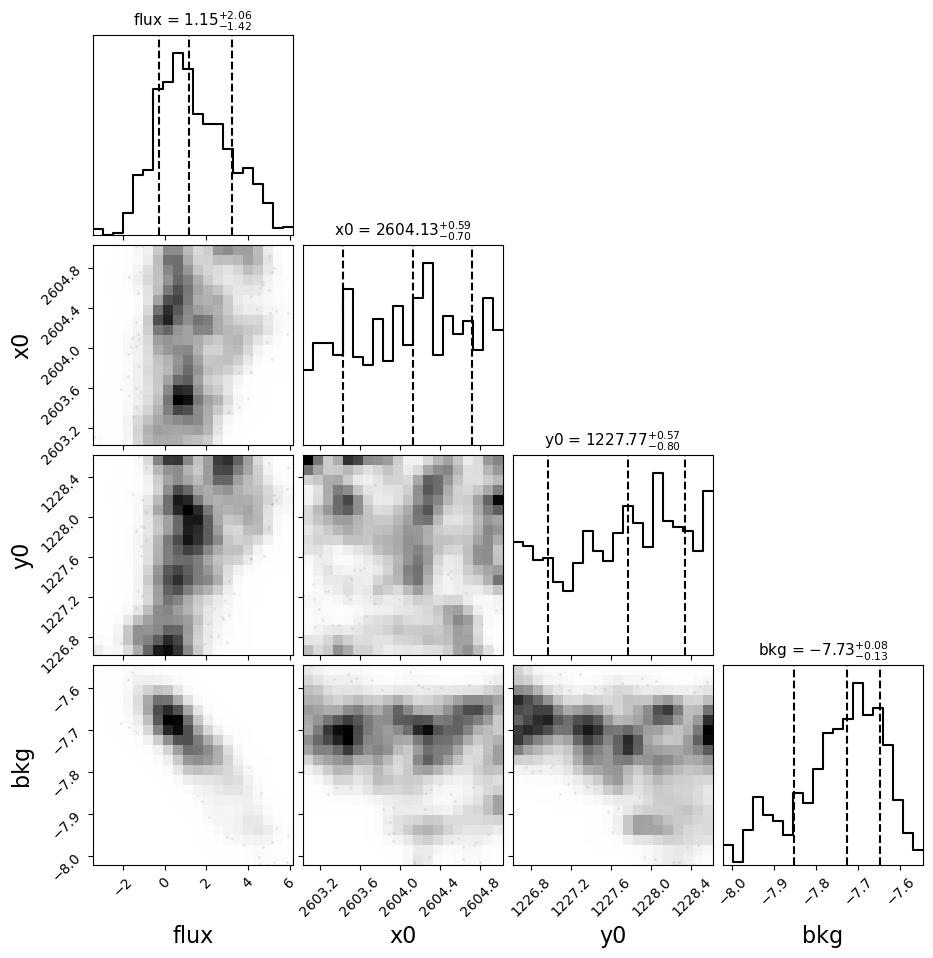

In [56]:
jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,10]},
                            fit_width=11,
                            background = 8.5,
                            fit_bkg=True,
                            fit_centroid=True, 
                            fit_flux=True,
                            centroidx_shift=0,
                            centroidy_shift=0,
                            psf_method='nest',
                            center_weight=25,npoints=200)

jwst_drz_obs.plot_psf_fit()
plt.show()

jwst_drz_obs.plot_psf_posterior(minweight=0.001)
plt.show()

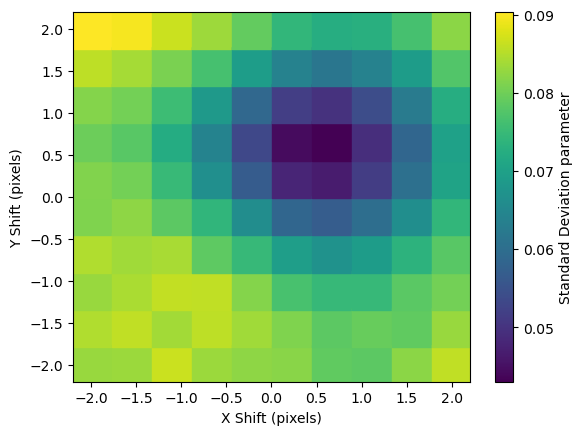

In [185]:
# plot 2D array, x v. y with color as std
plt.scatter(x_shift, y_shift, c=stddevs, s=800, marker='s') # s is a size of marker 
plt.viridis()
plt.xlabel('X Shift (pixels)')
plt.ylabel('Y Shift (pixels)')
plt.colorbar(label='Standard Deviation parameter')


Optimized Parameters: 
Standard Deviation of 2D Smoothed Background:  0.04304733954724273
x_shift:  0.6666666666666665 y_shift:  0.6666666666666665
background:  0.66


Text(0, 0.5, 'stddev(2D smooth bkgd model)')

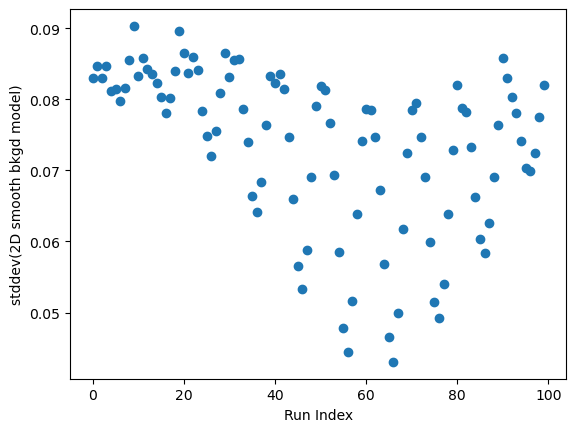

In [186]:
min_ind = np.argmin(stddevs)
print('Optimized Parameters: ')
print('Standard Deviation of 2D Smoothed Background: ', stddevs[min_ind]) 
print('x_shift: ', x_shift[min_ind],'y_shift: ', y_shift[min_ind])
print('background: ',back_ground[min_ind])

plt.plot(range(len(stddevs)), stddevs, marker='o', linestyle='none')
plt.xlabel('Run Index')
plt.ylabel('stddev(2D smooth bkgd model)')

2423it [00:01, 1775.16it/s, +200 | bound: 10 | nc: 1 | ncall: 10072 | eff(%): 26.570 | loglstar:   -inf < -0.457 <    inf | logz: -10.875 +/-  0.218 | dlogz:  0.001 >  0.209]   


[0.79487841]
0.3235708421158301
[0.25719948]
Finished PSF psf_photometry with median residuals of -1.97%


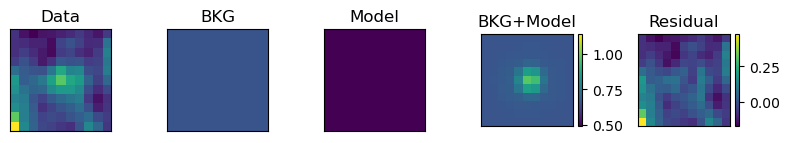

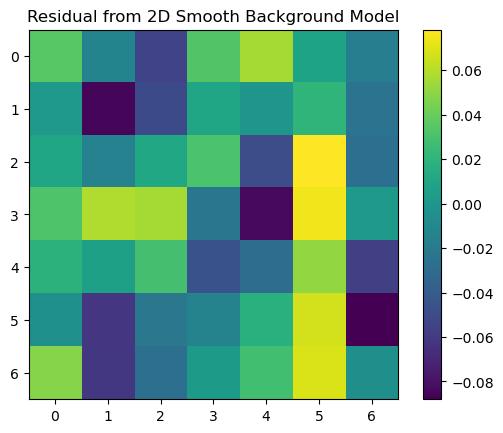

In [187]:
stddevs, x_shift, y_shift, back_ground = optimize_psf(drz_obs=jwst_drz_obs, drz_psf=psf_drz, sn_loc=sn_location, fwidth=11,
                                                      xshift_range=[x_shift[min_ind],x_shift[min_ind]], 
                                                      yshift_range=[y_shift[min_ind],y_shift[min_ind]], 
                                                      background_range=[back_ground[min_ind],back_ground[min_ind]],
                                                      nxs=1, nys=1, nbkg=1, plotting=True)

#### Print magnitude and error

In [188]:
print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

        ra        ...                        exp                        
----------------- ... --------------------------------------------------
53.38172788126466 ... jw02107-o021_t003_nircam_clear-f335m_jhat_i2d.fits
       mag               magerr      
------------------ ------------------
25.304548159497443 0.2597991511504836


#### Calculate Flux

In [189]:
# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  2.742715344196298e-07
FLUX ERROR [Jy] =  6.562875173056804e-08


# NIRCAM F360M

In [190]:
files = space_phot.util.filter_dict_from_list(glob.glob(lvl2),sn_location)['F360M']
files

filter_arr = []
file_arr = []
for flc in files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

filter = 'F360M'

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_flcs = files[tmp]
input_flcs = input_flcs.tolist()
input_flcs

drz_files = glob.glob(lvl3)

drz_files

filter_arr = []
file_arr = []
for flc in drz_files:
    
    input_file= flc
    tmp = fits.open(input_file)
    fltr = tmp[0].header['FILTER']
    filter_arr.append(fltr)
    file_arr.append(input_file)
    
print(filter_arr)
print(file_arr)

indices = [i for i, x in enumerate(filter_arr) if x == filter]
filters = np.array(filter_arr)
files = np.array(file_arr)

tmp = np.array(indices)
filters[tmp]
input_drzs = files[tmp]
input_drzs = input_drzs.tolist()
input_drzs

input_flcs


['F360M', 'F360M', 'F360M', 'F360M', 'F360M', 'F360M', 'F360M', 'F360M']
['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00002_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00001_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00004_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00003_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00002_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00003_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00004_nrcblong_cal.fits', '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00001_nrcblong_cal.fits']
['F300M', 'F1000W', 'F2100W', 

['/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00002_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00001_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00004_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00003_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00002_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_02101_00003_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00004_nrcblong_cal.fits',
 '/Users/sophiakressy/Desktop/Kavli/Summer_Project/SN1983V_4/lvl_2/jw02107021001_04101_00001_nrcblong_cal.fits']

2025-11-04 13:28:16,938 - stpipe.Image3Pipeline - INFO - Image3Pipeline instance created.
2025-11-04 13:28:16,938 - stpipe.Image3Pipeline.assign_mtwcs - INFO - AssignMTWcsStep instance created.
2025-11-04 13:28:16,939 - stpipe.Image3Pipeline.tweakreg - INFO - TweakRegStep instance created.
2025-11-04 13:28:16,940 - stpipe.Image3Pipeline.skymatch - INFO - SkyMatchStep instance created.
2025-11-04 13:28:16,941 - stpipe.Image3Pipeline.outlier_detection - INFO - OutlierDetectionStep instance created.
2025-11-04 13:28:16,941 - stpipe.Image3Pipeline.resample - INFO - ResampleStep instance created.
2025-11-04 13:28:16,942 - stpipe.Image3Pipeline.source_catalog - INFO - SourceCatalogStep instance created.
2025-11-04 13:28:17,062 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline running with args ('./temp_psf_dir/cal_data_asn.json',).
2025-11-04 13:28:17,067 - stpipe.Image3Pipeline - INFO - Step Image3Pipeline parameters are:
  pre_hooks: []
  post_hooks: []
  output_file: None
  output_dir:

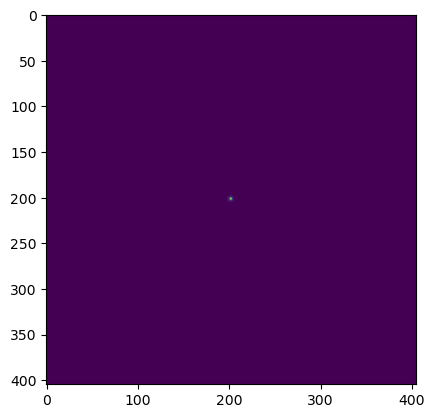

In [191]:
jwst_flc_obs = space_phot.observation2(input_flcs) 
jwst_drz_obs = space_phot.observation3(input_drzs[0])
psf_drz = space_phot.get_jwst3_psf(jwst_flc_obs, jwst_drz_obs, sn_location, num_psfs=4)
plt.imshow(psf_drz.data)
plt.show()

2804it [00:01, 1941.61it/s, +200 | bound: 17 | nc: 1 | ncall: 13205 | eff(%): 23.099 | loglstar:   -inf < -0.328 <    inf | logz: -12.686 +/-  0.237 | dlogz:  0.001 >  0.209]    


[0.80773989 0.42529267 0.39903388]
0.32630144615616946
[0.26356669 0.13877361 0.13020533]
Finished PSF psf_photometry with median residuals of -1.82%


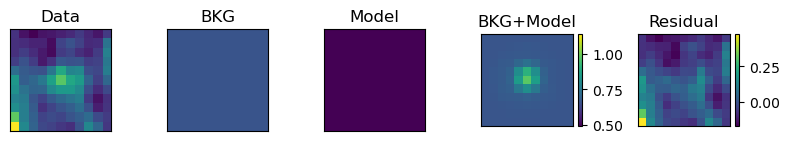

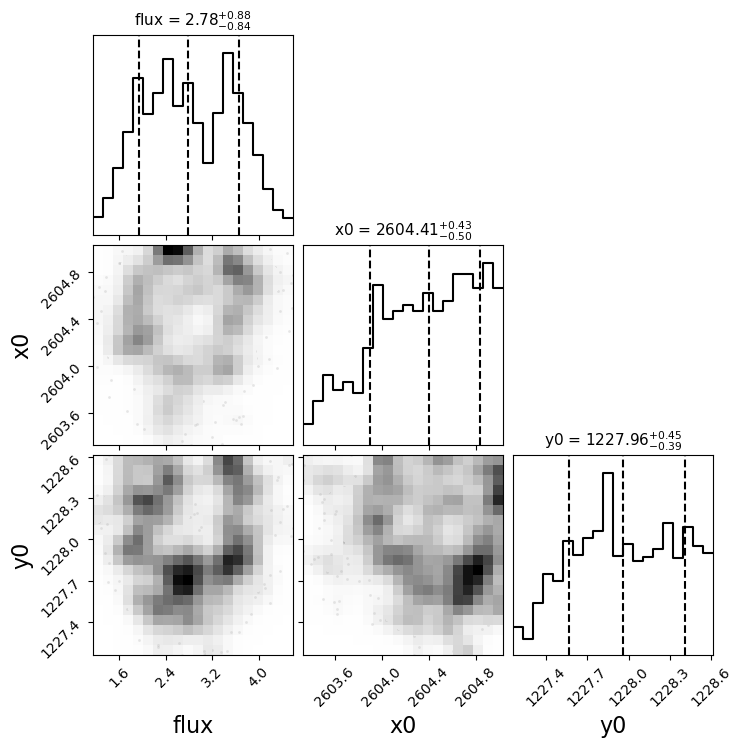

In [66]:
jwst_drz_obs.psf_photometry(psf_drz,sn_location,bounds={'flux':[-30000,40000],
                            'centroid':[-1,1],                              
                            'bkg':[-10,10]},
                            fit_width=11,
                            background = 0.66,
                            fit_bkg=False,
                            fit_centroid=True, 
                            fit_flux=True,
                            centroidx_shift=0,
                            centroidy_shift=0,
                            psf_method='nest',
                            center_weight=25,npoints=200)

jwst_drz_obs.plot_psf_fit()
plt.show()

jwst_drz_obs.plot_psf_posterior(minweight=0.001)
plt.show()

#### Print magnitude and error

In [67]:
# print(jwst_drz_obs.psf_result.phot_cal_table)
print(jwst_drz_obs.psf_result.phot_cal_table['mag','magerr'])
# print(jwst_drz_obs.psf_result.phot_cal_table['flux'])
# print(jwst_drz_obs.psf_result.phot_cal_table['fluxerr'])

mag_ab  = jwst_drz_obs.psf_result.phot_cal_table['mag'][0]
mag_err = jwst_drz_obs.psf_result.phot_cal_table['magerr'][0]

# Upper Limit
# print('Upper Limit: ', jwst_drz_obs.upper_limit(nsigma=5))

       mag              magerr      
----------------- ------------------
25.35581385905164 0.2747860028264839


#### Calculate Flux

In [68]:
flux_jy = 10**(-0.4 * (mag_ab + 48.6)) * 1e23
flux_err_jy = 0.4 * np.log(10) * flux_jy * mag_err
print('FLUX [Jy] = ', flux_jy)
print('FLUX ERROR [Jy] = ', flux_err_jy)


FLUX [Jy] =  2.616221174853648e-07
FLUX ERROR [Jy] =  6.621322527493609e-08


# SED